# Simulations from SkyMapper Data

In this notebook we look at how we can run simulations using the actual pointings and noise conditions from the [SkyMapper DR4](https://skymapper.anu.edu.au/data-release/). If you use the SkyMapper database to run simulations, please cite [Onken et. al. 2024](https://ui.adsabs.harvard.edu/abs/2024PASA...41...61O/abstract).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR
from lightcurvelynx.astro_utils.passbands import Passband, PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import DistModFromRedshift, X0FromDistMod
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.noise_models.base_noise_models import PoissonFluxNoiseModel
from lightcurvelynx.obstable.skymapper_obstable import SkyMapperObsTable
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve, simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
from lightcurvelynx.utils.extrapolate import LinearDecay
from lightcurvelynx.utils.plotting import plot_lightcurves

## SkyMapper Survey Data

The SkyMapper team has prepared a visits table parquet file that contains that necessary information for running LightCurveLynx (huge thank you to Christopher Onken for their help with this).  The data is available at: [https://www.mso.anu.edu.au/~onken/SkyMapper/SMSS_DR4.ccd_data2.LightCurveLynx.parquet](https://www.mso.anu.edu.au/~onken/SkyMapper/SMSS_DR4.ccd_data2.LightCurveLynx.parquet).

This notebook assumes it has been downloaded and is stored in "/data/obstable/SMSS_DR4.ccd_data2.LightCurveLynx.parquet".

In [2]:
table = pd.read_parquet(
    _LIGHTCURVELYNX_BASE_DATA_DIR / "obstable" / "SMSS_DR4.ccd_data2.LightCurveLynx.parquet"
)
print(f"Loaded table with {len(table)} rows and columns: {table.columns.tolist()}")
table.head()

Loaded table with 12630515 rows and columns: ['image_id', 'ccd', 'ra_deg', 'dec_deg', 'pa_deg', 'filter', 'mjd_midpt', 'exp_time', 'zeropoint', 'zeropoint_stdv', 'sb_mag', 'fwhm', 'elong']


,image_id,ccd,ra_deg,dec_deg,pa_deg,filter,mjd_midpt,exp_time,zeropoint,zeropoint_stdv,sb_mag,fwhm,elong
0,20180101162801,25,314.32684,-86.77332,300.0,r,58119.686319,30.0,26.979000,0.015,17.893999,2.77,1.109
1,20171215114730,32,310.79913,-88.21006,180.0,g,58102.491516,30.0,27.103001,0.012,21.521999,3.62,1.121
2,20171222125008,29,311.33861,-88.16419,90.0,g,58109.535000,30.0,27.176001,0.011,21.506001,3.34,1.081
3,20171222142830,32,312.05752,-88.24684,180.0,r,58109.603310,30.0,27.054001,0.011,20.941000,2.94,1.070
4,20171223140648,29,310.95270,-88.18184,90.0,v,58110.588241,30.0,24.444000,0.047,22.176001,3.89,1.077


The Skymapper visit table includes pointing information at the CCD level, including:

* image_id - The ID of the image.
* ccd - The ID of the CCD in the image.
* ra_deg - The RA coordinate of the center of the CCD in degrees.
* dec_deg - The Dec coordinate of the center of the CCD in degrees.
* pa_deg - Position angle of the positive-y-axis, East from North.
* filter - The string indicating the filter used.
* mjd_midpt - The time of the middle of the exposure in MJD.
* exp_time - The exposure time in seconds.
* zeropoint - The zeropoint in magntidue corresonding to 1 ADU.
* zeropoint_stdv - The standard deviation of the zeropoint.
* sb_mag - The sky brightness in magnitude per arcsec^2.
* fwhm - full-width at half-maximum of the PSF in pixels
* elong - ratio of semi-major-to-semi-minor axis lengths

We can use the `SkyMapperObsTable` class to transform the simulated data into an `ObsTable` data structure that can be used with LightCurveLynx's simulation infrastructure. This class performs several important preprocessing steps including: 1) Mapping the column names to standard names, 2) deriving noise information (zero points), 3) Building a CCD footprint (since `make_detector_footprint=True`), and 4) building spatial data structures for fast querying.

In [3]:
ops_data = SkyMapperObsTable(table, make_detector_footprint=True)
ops_data.head()

,image_id,ccd,ra,dec,rotation,filter,time,exptime,zp_mag_adu,zeropoint_stdv,skybrightness,fwhm,elong,zp,psf_footprint,sky_bg_e
0,20180101162801,25,314.32684,-86.77332,300.0,r,58119.686319,30.0,26.979000,0.015,17.893999,2.77,1.109,78.223740,70.394897,797.580750
1,20171215114730,32,310.79913,-88.21006,180.0,g,58102.491516,30.0,27.103001,0.012,21.521999,3.62,1.121,69.781181,120.226097,31.635500
2,20171222125008,29,311.33861,-88.16419,90.0,g,58109.535000,30.0,27.176001,0.011,21.506001,3.34,1.081,65.243668,102.346863,34.337921
3,20171222142830,32,312.05752,-88.24684,180.0,r,58109.603310,30.0,27.054001,0.011,20.941000,2.94,1.070,73.002586,79.300568,51.638603
4,20171223140648,29,310.95270,-88.18184,90.0,v,58110.588241,30.0,24.444000,0.047,22.176001,3.89,1.077,807.864685,138.829208,1.496146


Before we start simulating, we can look at the basic stats of the survey. We start with the bounds on times and their distribution.

Found 12630515 observations in time range [56730.6306134307, 59473.7668464037]


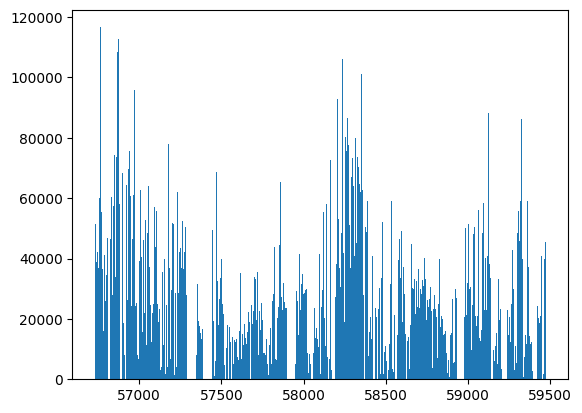

In [4]:
t_min, t_max = ops_data.time_bounds()
print(f"Found {len(ops_data)} observations in time range [{t_min}, {t_max}]")

_ = plt.hist(ops_data["time"], bins=500)

We can plot the tsurvey's footprint in the sky.

(<Figure size 640x480 with 1 Axes>, <WCSAxes: >)

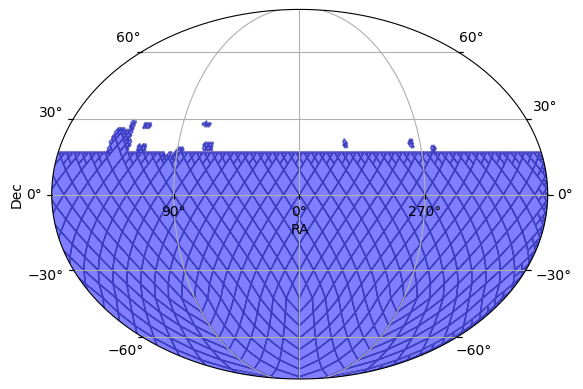

In [5]:
ops_data.plot_footprint(depth=8)

We can display the basic detector footprint (single CCD) in pixel space.  This was automatically derived the CCD size in the survey.

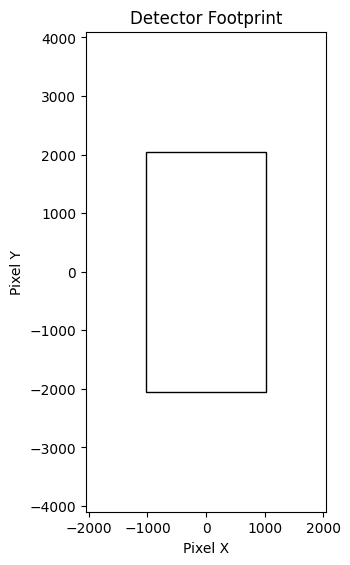

In [6]:
ops_data._detector_footprint.plot()

## Filter Information

The second piece of survey information that we need to run the simulation is the filter information. The SkyMapper filters are available from the SVO, so we can use the `PassbandGroup.from_svo()` function. By passing the name of the facility and instrument, we automatically download all the filters.

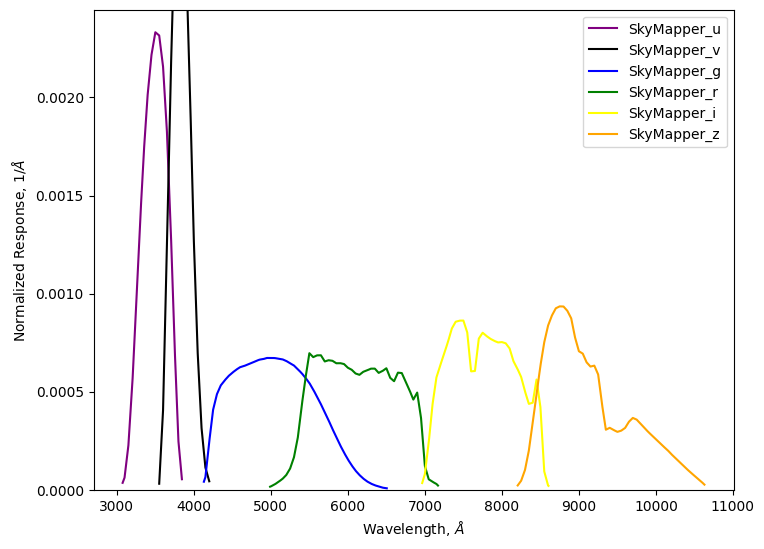

In [7]:
# The certificates for SVO Python access are currently messed up.
# So we predownloaded the passbands and are loading them from disk instead of from SVO.
# pb_group = PassbandGroup.from_svo("SkyMapper/SkyMapper")

pb_list = []
for filter_name in ["u", "v", "g", "r", "i", "z"]:
    pb_list.append(
        Passband.from_file(
            "SkyMapper",
            filter_name,
            table_path=_LIGHTCURVELYNX_BASE_DATA_DIR / "passbands" / "SkyMapper" / f"{filter_name}.xml",
        )
    )
pb_group = PassbandGroup(pb_list)
pb_group.plot()

The combination of the observations table and the bandpass filter provide all the survey information we need for the simulation. Next up is the model itself.

## Create the model

To generate simulated light curves we need to define the properties of the object from which to sample. In this notebook, we use [sncosmo](https://sncosmo.readthedocs.io/en/stable/)'s SALT2 model for Type Ia supernova. 

We start with "sampler" nodes that specify the distribution from which we would like to sample the object's parameters. We use the survey data to generate a multi-order coverage map of the survey footprint and sample (RA, dec) from that footprint. We sample redshift uniformly from [0.001, 0.1].

In [8]:
ra_dec_sampler = ApproximateMOCSampler.from_obstable(ops_data, depth=8)
redshift_sampler = NumpyRandomFunc("uniform", low=0.001, high=0.1)

We compute the physical parameters as follows:

In [9]:
# Use given values the cosmological parameters (H0=73.0, Omega_m=0.3).
# Then compue the distance modulus from the redshift (taking the redshift sampler as input).
distmod_func = DistModFromRedshift(redshift_sampler, H0=73.0, Omega_m=0.3)

# Sample x1, c, and m_abs from distributions motivated by typical SNIa values.
x1_func = NumpyRandomFunc("normal", loc=0, scale=2.0)
c_func = NumpyRandomFunc("normal", loc=0, scale=0.02)
m_abs_func = NumpyRandomFunc("normal", loc=-19.3, scale=0.1)

# Compute x0 from the other parameters using the standard Tripp formula,
# and the distance modulus from above.
x0_func = X0FromDistMod(
    distmod=distmod_func,  # Use the computed distance modulus from redshift as input.
    x1=x1_func,  # Use the sampled x1 values as input.
    c=c_func,  # Use the sampled c values as input.
    alpha=0.14,  # Use a constant alpha value motivated by typical SNIa fits.
    beta=3.1,  # Use a constant beta value motivated by typical SNIa fits.
    m_abs=m_abs_func,  # Use the sampled m_abs values as input.
)

# t0 for the super nova is sampled uniformly over the time range of the observations.
t0_func = NumpyRandomFunc("uniform", low=t_min, high=t_max)

Note that for more realistic surveys, we would likely want to first sample the host galaxy's properties (using something like [pzflow](https://jfcrenshaw.github.io/pzflow/) to define its parameters) and then sample the SALT2 parameters based on the host's details. In general, LightCurveLynx provides the ability to define a complex directed acyclic graph (DAG) of parameters.

We then define the model using the `SncosmoWrapperModel` class. All of the parameters are set using the samplers defined above.

In [10]:
source = SncosmoWrapperModel(
    "salt2-h17",  # Model name
    t0=t0_func,
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=ra_dec_sampler.ra,
    dec=ra_dec_sampler.dec,
    redshift=redshift_sampler,
    node_label="source",
    time_extrapolation=LinearDecay(50.0),
)

## Generate the simulations

We can now generate random simulations with all the information defined above. The light curves are written in the [nested-pandas](https://github.com/lincc-frameworks/nested-pandas) format for easy analysis. 

In [11]:
survey_info = SurveyInfo(
    obstable=ops_data,
    passbands=pb_group,
    noise_model=PoissonFluxNoiseModel(),
    survey_name="SkyMapper",
)

lightcurves = simulate_lightcurves(
    source,  # The model we are simulating.
    100,  # The number of simulations to run,
    survey_info,  # The survey information
    rest_time_window_offset=(-100, 200),  # Simulate from -100 to +200 days of t0 in the rest frame.
)

# Show the first few entries,
lightcurves.drop(columns=["params"]).head()

Simulating: 100%|██████████| 100/100 [00:00<00:00, 1140.89obj/s]


id          ra        dec  nobs            t0         z  \
0   0  198.792259  -6.503723    32  57446.885748  0.072282   
1   1  183.238081 -51.926956     6  57536.390801  0.032873   
2   2  320.969914  -3.706064    21  58147.570388  0.070159   
3   3    4.942177  -8.347133     8  59006.344826  0.015092   
4   4  173.332310 -39.096202     8  59195.888102  0.060123   

                                          lightcurve  
0  [{mjd: 57531.621424, filter: 'r', flux: 23293....  
1  [{mjd: 57471.579884, filter: 'z', flux: -13953...  
2  [{mjd: 58317.672245, filter: 'v', flux: 1747.4...  
3  [{mjd: 59109.622789, filter: 'v', flux: -24420...  
4  [{mjd: 59327.505216, filter: 'v', flux: -21365...

In some of the simulations, you will see the light curve entry is `None`, indicating no data. This is due to how we are doing sampling. The code is *first* choosing an (RA, dec) from the survey footprint and then *independently* choosing a t0. LightCurveLynx then computes when the survey sees that position and further filters those instances using the bounds [t0-50, t0+100] (from the `rest_time_window_offset` parameter). While this approach works reasonably well for surveys that are regularly revisiting each location, it is non-optimal for other surveys. In this case we are seeing the result of choosing (RA, dec, t0) combinations that end up with not observations.

**The LightCurveLynx team is looking into how best to handle this.** In the meantime, you can drop non-observed supernovas by using `dropna` on the results table.

In [12]:
lightcurves = lightcurves.dropna(subset=["lightcurve"])
print(f"After dropping entries with no lightcurve, we have {len(lightcurves)} lightcurves to show.")

After dropping entries with no lightcurve, we have 73 lightcurves to show.


Now let's plot the first five (non-empty) random light curves. For reference we will also plot the underlying curve and the t0 line.

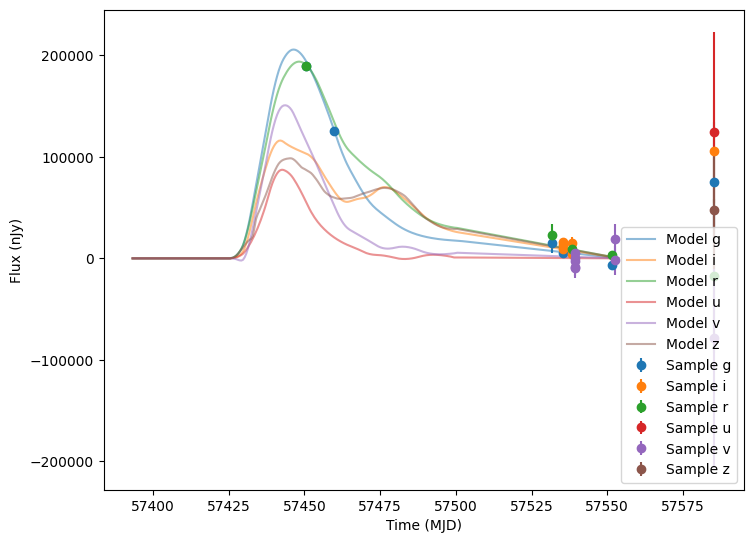

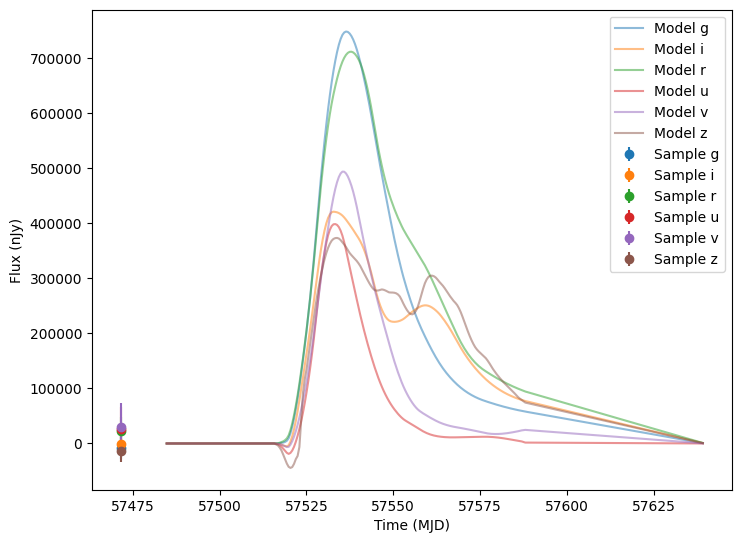

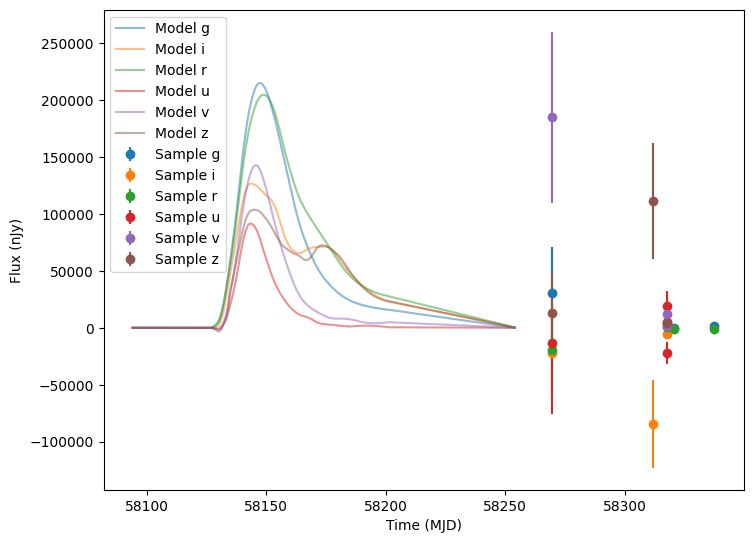

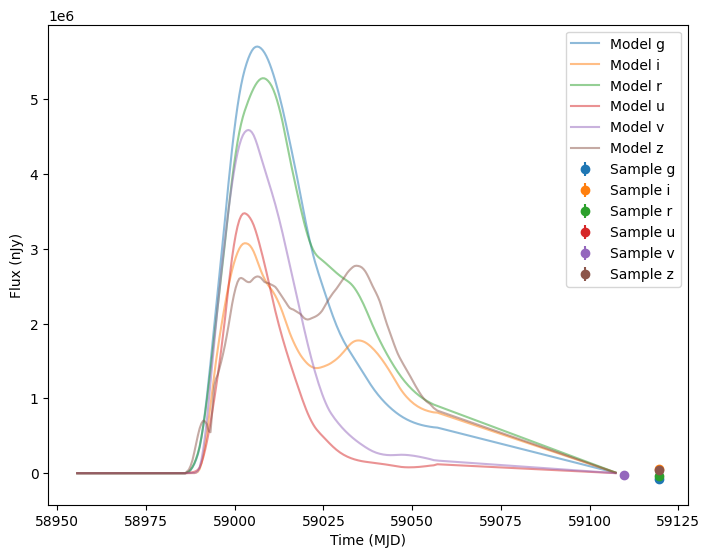

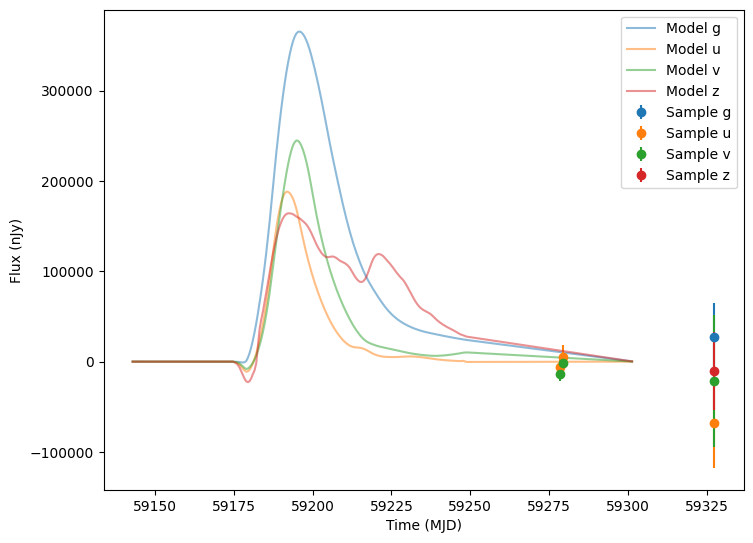

In [13]:
num_to_show = np.min([5, len(lightcurves)])

for idx in range(num_to_show):
    # Extract the row for this object.
    lc = lightcurves.iloc[idx]

    # Unpack the nested columns (filters, mjd, flux, and flux error). This is the
    # data from the simulation itself.
    lc_filters = np.asarray(lc["lightcurve"]["filter"], dtype=str)
    lc_mjd = np.asarray(lc["lightcurve"]["mjd"], dtype=float)
    lc_flux = np.asarray(lc["lightcurve"]["flux"], dtype=float)
    lc_fluxerr = np.asarray(lc["lightcurve"]["fluxerr"], dtype=float)

    # Extract the parameters used during the simulation of this object (stored in the "params" column).
    # Use that to compute the noise-free light curve for this object, which we will plot alongside the
    # simulated light curve.
    noise_free_lcs = compute_single_noise_free_lightcurve(
        source,
        GraphState.from_dict(lc["params"]),
        pb_group,
        rest_frame_phase_min=-50.0,  # 50 days before t0
        rest_frame_phase_max=100.0,  # 100 days after t0
        rest_frame_phase_step=0.5,  # 2 samples per day
    )

    plot_lightcurves(
        fluxes=lc_flux,
        times=lc_mjd,
        fluxerrs=lc_fluxerr,
        filters=lc_filters,
        underlying_model=noise_free_lcs,
    )